In [51]:
import pandas as pd

In [52]:
df=pd.read_csv("used-bikes.csv")

In [53]:
df

,bike_name,price,city,kms_driven,owner,age,power,brand,Original Price
0,TVS Star City Plus Dual Tone 110cc,35000,Ahmedabad,17654,First Owner,3,110,TVS,82500
1,Royal Enfield Classic 350cc,119900,Delhi,11000,First Owner,4,350,Royal Enfield,230000
2,Triumph Daytona 675R,600000,Delhi,110,First Owner,8,675,Triumph,1100000
3,TVS Apache RTR 180cc,65000,Bangalore,16329,First Owner,4,180,TVS,140000
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000,Bangalore,10000,First Owner,3,150,Yamaha,150000
...,...,...,...,...,...,...,...,...,...
7307,Hero Hunk Rear Disc 150cc,25000,Delhi,48587,First Owner,8,150,Hero,120000
7308,Bajaj Avenger 220cc,35000,Bangalore,60000,First Owner,9,220,Bajaj,160000
7309,Harley-Davidson Street 750 ABS,450000,Jodhpur,3430,First Owner,4,750,Harley-Davidson,630000
7310,Bajaj Dominar 400 ABS,139000,Hyderabad,21300,First Owner,4,400,Bajaj,245000


In [54]:
import pandas as pd 
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns 


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error,r2_score



In [55]:
df.head()

,bike_name,price,city,kms_driven,owner,age,power,brand,Original Price
0,TVS Star City Plus Dual Tone 110cc,35000,Ahmedabad,17654,First Owner,3,110,TVS,82500
1,Royal Enfield Classic 350cc,119900,Delhi,11000,First Owner,4,350,Royal Enfield,230000
2,Triumph Daytona 675R,600000,Delhi,110,First Owner,8,675,Triumph,1100000
3,TVS Apache RTR 180cc,65000,Bangalore,16329,First Owner,4,180,TVS,140000
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000,Bangalore,10000,First Owner,3,150,Yamaha,150000


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7312 entries, 0 to 7311
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   bike_name       7312 non-null   object
 1   price           7312 non-null   int64 
 2   city            7312 non-null   object
 3   kms_driven      7312 non-null   int64 
 4   owner           7312 non-null   object
 5   age             7312 non-null   int64 
 6   power           7312 non-null   int64 
 7   brand           7312 non-null   object
 8   Original Price  7312 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 514.3+ KB


In [57]:
df.describe()

,price,kms_driven,age,power,Original Price
count,7.312000e+03,7312.000000,7312.000000,7312.000000,7.312000e+03
mean,8.495145e+04,23949.871718,6.733862,228.496991,1.823393e+05
std,1.207519e+05,27340.904392,3.857574,158.035118,1.835454e+05
min,4.400000e+03,1.000000,1.000000,100.000000,5.000000e+04
25%,3.000000e+04,10148.500000,4.000000,125.000000,9.000000e+04
50%,5.500000e+04,19000.000000,6.000000,160.000000,1.500000e+05
75%,1.000000e+05,30396.750000,8.000000,350.000000,2.150000e+05
max,1.900000e+06,750000.000000,63.000000,1800.000000,2.750000e+06


In [58]:
df['brand']=df['brand'].str.lower().str.strip()
df

,bike_name,price,city,kms_driven,owner,age,power,brand,Original Price
0,TVS Star City Plus Dual Tone 110cc,35000,Ahmedabad,17654,First Owner,3,110,tvs,82500
1,Royal Enfield Classic 350cc,119900,Delhi,11000,First Owner,4,350,royal enfield,230000
2,Triumph Daytona 675R,600000,Delhi,110,First Owner,8,675,triumph,1100000
3,TVS Apache RTR 180cc,65000,Bangalore,16329,First Owner,4,180,tvs,140000
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000,Bangalore,10000,First Owner,3,150,yamaha,150000
...,...,...,...,...,...,...,...,...,...
7307,Hero Hunk Rear Disc 150cc,25000,Delhi,48587,First Owner,8,150,hero,120000
7308,Bajaj Avenger 220cc,35000,Bangalore,60000,First Owner,9,220,bajaj,160000
7309,Harley-Davidson Street 750 ABS,450000,Jodhpur,3430,First Owner,4,750,harley-davidson,630000
7310,Bajaj Dominar 400 ABS,139000,Hyderabad,21300,First Owner,4,400,bajaj,245000


In [59]:
df['city']=df['city'].str.lower().str.strip()
df

,bike_name,price,city,kms_driven,owner,age,power,brand,Original Price
0,TVS Star City Plus Dual Tone 110cc,35000,ahmedabad,17654,First Owner,3,110,tvs,82500
1,Royal Enfield Classic 350cc,119900,delhi,11000,First Owner,4,350,royal enfield,230000
2,Triumph Daytona 675R,600000,delhi,110,First Owner,8,675,triumph,1100000
3,TVS Apache RTR 180cc,65000,bangalore,16329,First Owner,4,180,tvs,140000
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000,bangalore,10000,First Owner,3,150,yamaha,150000
...,...,...,...,...,...,...,...,...,...
7307,Hero Hunk Rear Disc 150cc,25000,delhi,48587,First Owner,8,150,hero,120000
7308,Bajaj Avenger 220cc,35000,bangalore,60000,First Owner,9,220,bajaj,160000
7309,Harley-Davidson Street 750 ABS,450000,jodhpur,3430,First Owner,4,750,harley-davidson,630000
7310,Bajaj Dominar 400 ABS,139000,hyderabad,21300,First Owner,4,400,bajaj,245000


In [60]:
df.drop(['bike_name'],axis=1, inplace=True)

In [61]:
df

,price,city,kms_driven,owner,age,power,brand,Original Price
0,35000,ahmedabad,17654,First Owner,3,110,tvs,82500
1,119900,delhi,11000,First Owner,4,350,royal enfield,230000
2,600000,delhi,110,First Owner,8,675,triumph,1100000
3,65000,bangalore,16329,First Owner,4,180,tvs,140000
4,80000,bangalore,10000,First Owner,3,150,yamaha,150000
...,...,...,...,...,...,...,...,...
7307,25000,delhi,48587,First Owner,8,150,hero,120000
7308,35000,bangalore,60000,First Owner,9,220,bajaj,160000
7309,450000,jodhpur,3430,First Owner,4,750,harley-davidson,630000
7310,139000,hyderabad,21300,First Owner,4,400,bajaj,245000


In [62]:
df.duplicated().sum()

np.int64(1)

In [63]:
#df.drop_duplicates(inplace=True)

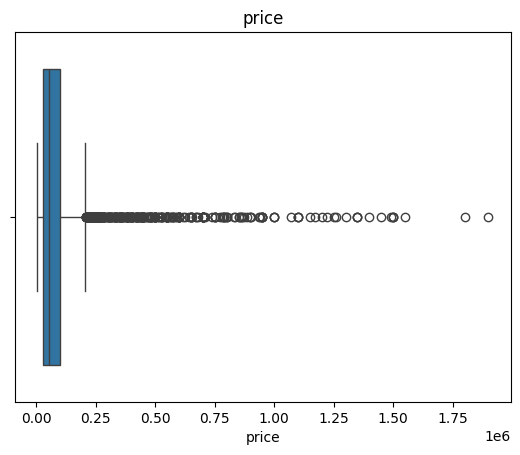

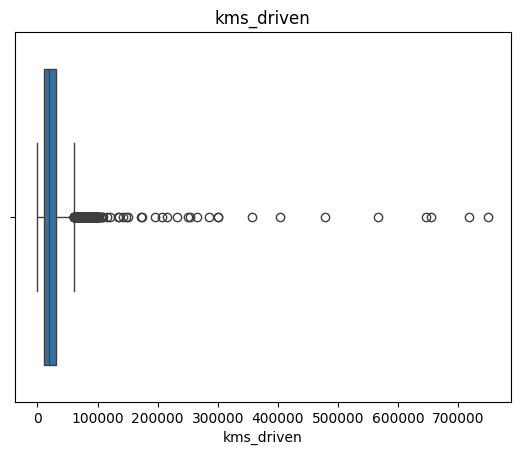

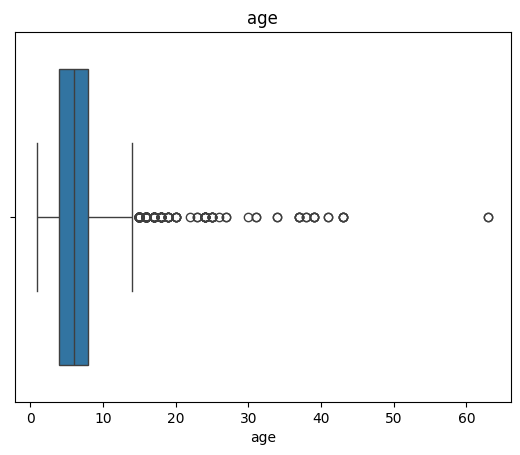

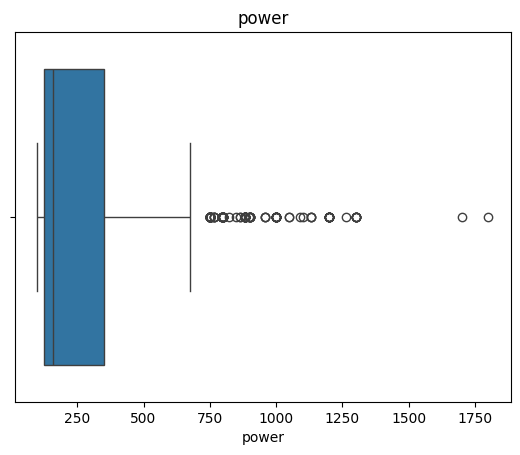

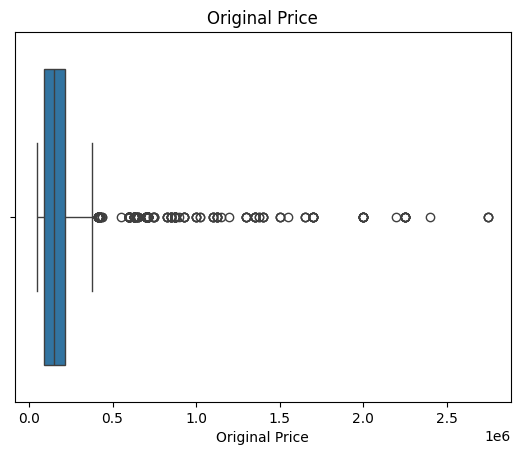

In [64]:
for col in df.select_dtypes(include=[np.number]).columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [65]:
df_num=df.select_dtypes(include=[np.number])

In [66]:
df_num

,price,kms_driven,age,power,Original Price
0,35000,17654,3,110,82500
1,119900,11000,4,350,230000
2,600000,110,8,675,1100000
3,65000,16329,4,180,140000
4,80000,10000,3,150,150000
...,...,...,...,...,...
7307,25000,48587,8,150,120000
7308,35000,60000,9,220,160000
7309,450000,3430,4,750,630000
7310,139000,21300,4,400,245000


In [67]:
from sklearn.impute import KNNImputer
q1=df_num.quantile(0.25)
q3=df_num.quantile(0.75)

iqr= q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
df_num[(df_num<=lower) | (df_num>=upper)] = np.nan


In [68]:
df_num.isnull().sum()

price             349
kms_driven        334
age               332
power             168
Original Price    256
dtype: int64

In [69]:
imputer=KNNImputer(n_neighbors=3)
df_clean=pd.DataFrame(imputer.fit_transform(df_num),columns=df_num.columns)

In [70]:
df_clean

,price,kms_driven,age,power,Original Price
0,35000.000000,17654.0,3.0,110.0,82500.000000
1,119900.000000,11000.0,4.0,350.0,230000.000000
2,140000.000000,110.0,8.0,675.0,296666.666667
3,65000.000000,16329.0,4.0,180.0,140000.000000
4,80000.000000,10000.0,3.0,150.0,150000.000000
...,...,...,...,...,...
7307,25000.000000,48587.0,8.0,150.0,120000.000000
7308,35000.000000,60000.0,9.0,220.0,160000.000000
7309,72666.666667,3430.0,4.0,150.0,130000.000000
7310,139000.000000,21300.0,4.0,400.0,245000.000000


In [71]:
df_clean.isnull().sum()

price             0
kms_driven        0
age               0
power             0
Original Price    0
dtype: int64

In [72]:
df_clean.columns

Index(['price', 'kms_driven', 'age', 'power', 'Original Price'], dtype='object')

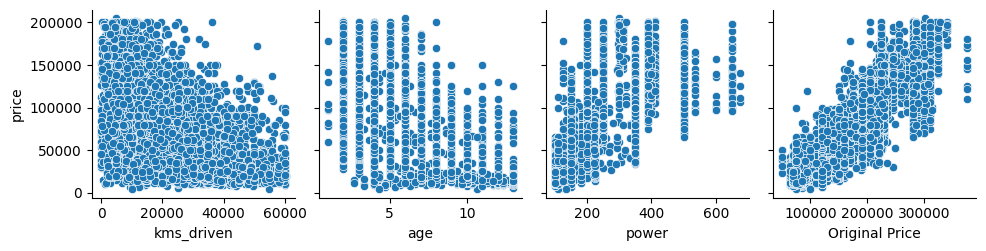

In [73]:
sns.pairplot(df_clean,x_vars=['kms_driven','age','power','Original Price'],y_vars=['price'])

In [74]:
df

,price,city,kms_driven,owner,age,power,brand,Original Price
0,35000,ahmedabad,17654,First Owner,3,110,tvs,82500
1,119900,delhi,11000,First Owner,4,350,royal enfield,230000
2,600000,delhi,110,First Owner,8,675,triumph,1100000
3,65000,bangalore,16329,First Owner,4,180,tvs,140000
4,80000,bangalore,10000,First Owner,3,150,yamaha,150000
...,...,...,...,...,...,...,...,...
7307,25000,delhi,48587,First Owner,8,150,hero,120000
7308,35000,bangalore,60000,First Owner,9,220,bajaj,160000
7309,450000,jodhpur,3430,First Owner,4,750,harley-davidson,630000
7310,139000,hyderabad,21300,First Owner,4,400,bajaj,245000


In [75]:
df_clean

,price,kms_driven,age,power,Original Price
0,35000.000000,17654.0,3.0,110.0,82500.000000
1,119900.000000,11000.0,4.0,350.0,230000.000000
2,140000.000000,110.0,8.0,675.0,296666.666667
3,65000.000000,16329.0,4.0,180.0,140000.000000
4,80000.000000,10000.0,3.0,150.0,150000.000000
...,...,...,...,...,...
7307,25000.000000,48587.0,8.0,150.0,120000.000000
7308,35000.000000,60000.0,9.0,220.0,160000.000000
7309,72666.666667,3430.0,4.0,150.0,130000.000000
7310,139000.000000,21300.0,4.0,400.0,245000.000000


In [76]:
df.drop(['price','kms_driven','age','power','Original Price'], inplace=True,axis=1)

In [77]:
ori_df=pd.concat([df,df_clean],axis=1)

In [78]:
ori_df.isnull().sum()

city              0
owner             0
brand             0
price             0
kms_driven        0
age               0
power             0
Original Price    0
dtype: int64

In [79]:
ori_df

,city,owner,brand,price,kms_driven,age,power,Original Price
0,ahmedabad,First Owner,tvs,35000.000000,17654.0,3.0,110.0,82500.000000
1,delhi,First Owner,royal enfield,119900.000000,11000.0,4.0,350.0,230000.000000
2,delhi,First Owner,triumph,140000.000000,110.0,8.0,675.0,296666.666667
3,bangalore,First Owner,tvs,65000.000000,16329.0,4.0,180.0,140000.000000
4,bangalore,First Owner,yamaha,80000.000000,10000.0,3.0,150.0,150000.000000
...,...,...,...,...,...,...,...,...
7307,delhi,First Owner,hero,25000.000000,48587.0,8.0,150.0,120000.000000
7308,bangalore,First Owner,bajaj,35000.000000,60000.0,9.0,220.0,160000.000000
7309,jodhpur,First Owner,harley-davidson,72666.666667,3430.0,4.0,150.0,130000.000000
7310,hyderabad,First Owner,bajaj,139000.000000,21300.0,4.0,400.0,245000.000000


In [80]:
multi_df = ori_df.select_dtypes(include=[np.number]).drop(['price','Original Price'], axis=1)

In [81]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df=pd.DataFrame()
vif_df['features']=multi_df.columns
vif_df['vif']=[variance_inflation_factor(multi_df.values,i) for i in range(multi_df.shape[1])]

In [82]:
vif_df

,features,vif
0,kms_driven,4.433435
1,age,5.764984
2,power,2.391951


In [83]:
ori_df.drop('Original Price',axis=1,inplace=True)

<Axes: xlabel='brand'>

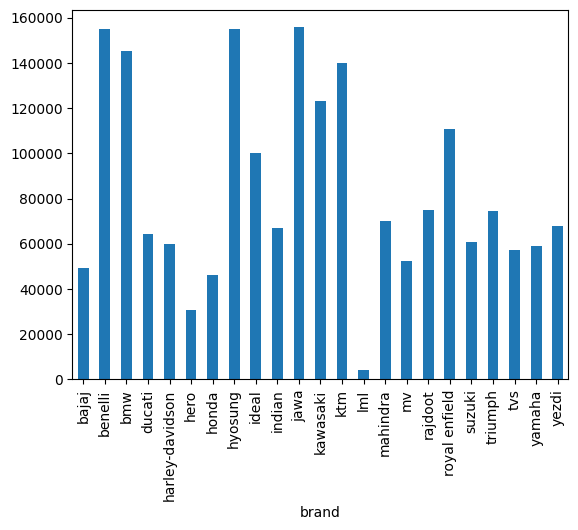

In [84]:
ori_df.groupby('brand')['price'].mean().plot(kind='bar')


In [85]:
ori_df['brand'].value_counts()

brand
bajaj              2031
royal enfield      1364
hero               1167
honda               672
yamaha              651
tvs                 481
ktm                 375
suzuki              203
harley-davidson      91
kawasaki             61
hyosung              53
mahindra             50
benelli              46
triumph              21
ducati               19
bmw                  10
jawa                  7
indian                3
mv                    3
rajdoot               1
lml                   1
yezdi                 1
ideal                 1
Name: count, dtype: int64

In [86]:
ori_df=ori_df[ori_df['brand'].map((ori_df['brand'].value_counts())>100)]

In [87]:
ori_df['owner'].value_counts()

owner
First Owner             6311
Second Owner             546
Third Owner               76
Fourth Owner Or More      11
Name: count, dtype: int64

In [88]:
#categorical encoding

le_owner=LabelEncoder()
ori_df['owner_encoded'] = le_owner.fit_transform(ori_df['owner'])

le_brand=LabelEncoder()
ori_df['brand_encoded'] = le_brand.fit_transform(ori_df['brand'])

le_city=LabelEncoder()
ori_df['city_encoded'] = le_city.fit_transform(ori_df['city'])

C:\Users\saura\AppData\Local\Temp\ipykernel_12796\3276827947.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ori_df['owner_encoded'] = le_owner.fit_transform(ori_df['owner'])
C:\Users\saura\AppData\Local\Temp\ipykernel_12796\3276827947.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ori_df['brand_encoded'] = le_brand.fit_transform(ori_df['brand'])
C:\Users\saura\AppData\Local\Temp\ipykernel_12796\3276827947.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataF

In [89]:
ori_df

,city,owner,brand,price,kms_driven,age,power,owner_encoded,brand_encoded,city_encoded
0,ahmedabad,First Owner,tvs,35000.0,17654.0,3.0,110.0,0,6,6
1,delhi,First Owner,royal enfield,119900.0,11000.0,4.0,350.0,0,4,111
3,bangalore,First Owner,tvs,65000.0,16329.0,4.0,180.0,0,6,43
4,bangalore,First Owner,yamaha,80000.0,10000.0,3.0,150.0,0,7,43
5,delhi,First Owner,yamaha,53499.0,25000.0,6.0,150.0,0,7,111
...,...,...,...,...,...,...,...,...,...,...
7306,bangalore,First Owner,bajaj,50000.0,29134.0,7.0,220.0,0,0,43
7307,delhi,First Owner,hero,25000.0,48587.0,8.0,150.0,0,1,111
7308,bangalore,First Owner,bajaj,35000.0,60000.0,9.0,220.0,0,0,43
7310,hyderabad,First Owner,bajaj,139000.0,21300.0,4.0,400.0,0,0,175


In [90]:
x=ori_df[['kms_driven' , 'age' , 'power' , 'owner_encoded' , 'city_encoded','brand_encoded']]

y=ori_df['price']

In [91]:
x_train,x_test,y_train,y_test = train_test_split(x , y, test_size=0.2 , random_state=22)

In [92]:
scaler=StandardScaler()
x_train_scaler= scaler.fit_transform(x_train)
x_test_scaler= scaler.fit_transform(x_test)

In [93]:
import statsmodels.api as sm

In [94]:
x_train,x_test,=sm.add_constant(x_train_scaler),sm.add_constant(x_test_scaler)

In [95]:
x_train

array([[ 1.        , -0.17916035, -0.12829748, ...,  4.55116916,
         1.49587563,  0.20097621],
       [ 1.        ,  2.1166872 ,  0.60505099, ..., -0.31008158,
        -0.56848096, -1.06672573],
       [ 1.        ,  0.85322854, -0.12829748, ..., -0.31008158,
         1.01251409,  0.20097621],
       ...,
       [ 1.        , -0.07372362, -0.49497171, ..., -0.31008158,
        -0.89072199, -0.2215911 ],
       [ 1.        , -0.05813087,  0.60505099, ..., -0.31008158,
        -1.25324315,  1.46867815],
       [ 1.        , -0.20759856, -0.49497171, ..., -0.31008158,
        -0.35701029, -0.64415842]], shape=(5555, 7))

In [96]:
model=sm.OLS(y_train,x_train).fit()

In [97]:
x_train.shape

(5555, 7)

In [98]:
y_train.shape


(5555,)

In [99]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     3189.
Date:                Thu, 01 Jan 2026   Prob (F-statistic):               0.00
Time:                        18:54:26   Log-Likelihood:                -63034.
No. Observations:                5555   AIC:                         1.261e+05
Df Residuals:                    5548   BIC:                         1.261e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.496e+04    275.270    236.001      0.0

In [100]:
lr=LinearRegression()

In [101]:
lr.fit(x_train_scaler,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [102]:
y_pred=lr.predict(x_test_scaler)


In [103]:
r2_score(y_test,y_pred)

0.7606487634426862

In [104]:
import joblib
joblib.dump(lr, 'used_bike_price_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_brand, 'brand_encoder.pkl')
joblib.dump(le_owner,'owner_encoder.pkl')
joblib.dump(le_city, 'city_encoder.pkl')
print('model and encoders savedsucessfully')

model and encoders savedsucessfully
